## TASK 3: Car Price Prediction with Machine Learning

Collect car-related features like **brand goodwill, horsepower, mileage,** etc.
- Train a **regression model** to predict car prices based on these features.
- Handle **data preprocessing, feature engineering, and model evaluation.**
- Use Python libraries like **Pandas, Scikit-learn and Matplotlib** for the workflow.
- Understand real-world applications of **machine learning in price prediction.**

**Import Required Libraries**

In [163]:

# Import basic labraries which EDA and Visualizations
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore all Warnings
import warnings
warnings.filterwarnings('ignore')

# for Data splitting into train and test
from sklearn.model_selection import train_test_split

# Import Base Model's libraries 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Import Classification Model Evaluation library
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

**Load Dataset**

In [164]:
car_data = pd.read_csv(r"C:\Users\Admin\Downloads\archive\car data.csv")

car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


**Exploratory Data Analysis (EDA)**

In [165]:
car_data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


Let's check info of data, it give's overview of dataset

In [166]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Here we observed that present price column is confused while doing analysis

actually present price is showroom price

let's change present price into `Showroon_price`

In [167]:
car_data.rename(columns = {'Present_Price':"Showroom_Price"}, inplace = True)
car_data.head()

,Car_Name,Year,Selling_Price,Showroom_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


similarily here Year col doesn't represent's any thing because we predicting the furture car selli price 

So, here we have subtract the current year - car manufactured year's

In [168]:
# Create Car age col calculate the present age of car
car_data["Car_Age"] = 2026 - car_data["Year"]

# Drop the year column
car_data = car_data.drop("Year", axis = 1)

In [169]:
car_data.head()

,Car_Name,Selling_Price,Showroom_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


Now model can easily to present price of car on the bases of car age

**Statistical Analysis**

In [170]:
car_data.describe()

,Selling_Price,Showroom_Price,Driven_kms,Owner,Car_Age
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,0.043189,12.372093
std,5.082812,8.642584,38886.883882,0.247915,2.891554
min,0.100000,0.320000,500.000000,0.000000,8.000000
25%,0.900000,1.200000,15000.000000,0.000000,10.000000
50%,3.600000,6.400000,32000.000000,0.000000,12.000000
75%,6.000000,9.900000,48767.000000,0.000000,14.000000
max,35.000000,92.600000,500000.000000,3.000000,23.000000


let's remove `Car_Name` col which is not useful for price prediction

In [171]:
car_data.drop('Car_Name', axis = 1, inplace = True)

In [172]:
# check null values
car_data.isna().sum().sum()

0

In [173]:
# check duplicated values
car_data.duplicated().sum()

2

In [174]:
car_data.drop_duplicates(inplace = True)
car_data.duplicated().sum()

0

Check outliers is present in our data

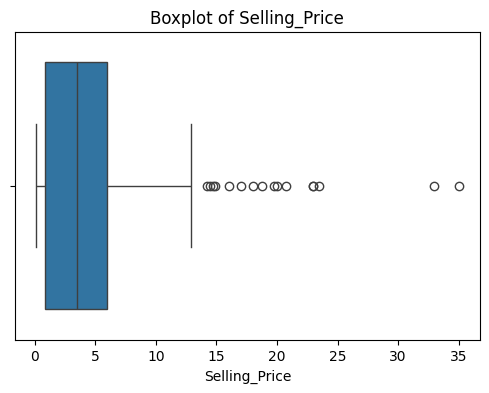

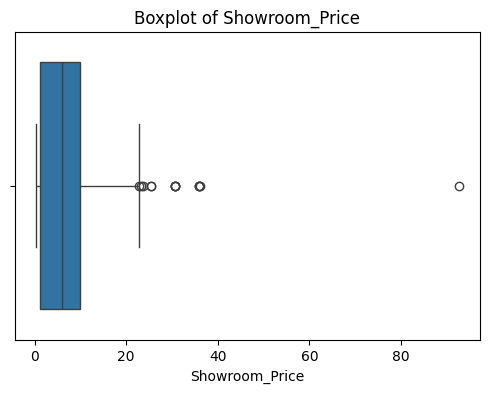

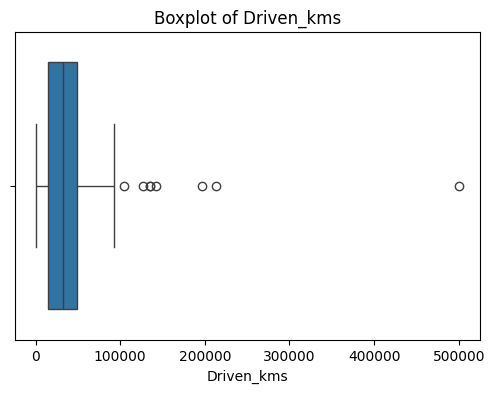

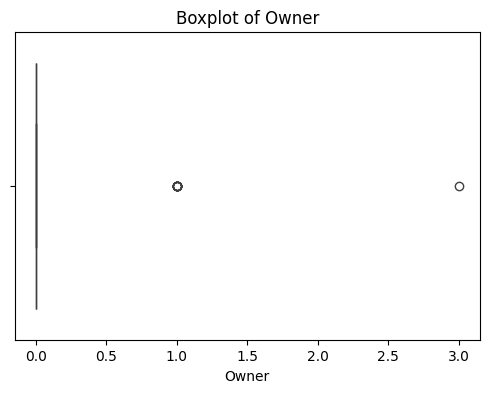

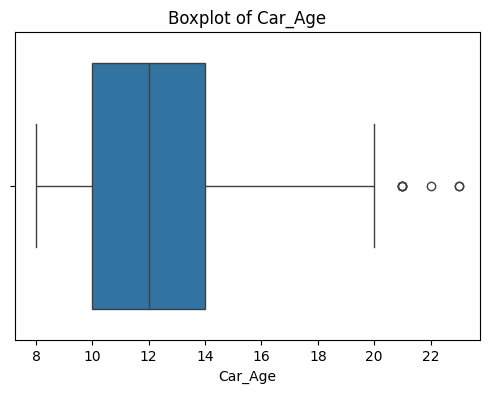

In [175]:
for cols in car_data.columns:
    if car_data[cols].dtypes != 'object':
        plt.figure(figsize=(6,4))          # optional: control figure size
        sns.boxplot(x=car_data[cols])       # pass column as x
        plt.title(f"Boxplot of {cols}")     # add title for clarity
        plt.show()

the outliers col's are [Car_Age, Selling price, Present price, Driven kms, Owner]

`car_age` col is important for predicting  price of car age may be higher or lower

`Selling and Showroom prices` may high or low depending on car brand

Here every col is important for predicting a price 

if `car age` is low price will be high cost similarly car age is high price will be low cost.

similarly if `Driven kms` is less price will be high. if it is high cost will be low 

`Final Colculsion:` every col is important for car price predcition so, here we are not removing col's

In [176]:
car_data["Owner"].unique()

array([0, 1, 3], dtype=int64)

0 Reprsents First Owner

1 Second Owner

3 Third Owner

Let's convert all categorical values into numeric

because model understood only numerical values


In [177]:
car_data['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [178]:
car_data = pd.get_dummies(car_data, drop_first = True)
car_data.head().info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Selling_Price            5 non-null      float64
 1   Showroom_Price           5 non-null      float64
 2   Driven_kms               5 non-null      int64  
 3   Owner                    5 non-null      int64  
 4   Car_Age                  5 non-null      int64  
 5   Fuel_Type_Diesel         5 non-null      bool   
 6   Fuel_Type_Petrol         5 non-null      bool   
 7   Selling_type_Individual  5 non-null      bool   
 8   Transmission_Manual      5 non-null      bool   
dtypes: bool(4), float64(2), int64(3)
memory usage: 260.0 bytes


In [179]:
# Convert all boolean columns to integers
car_data = car_data.astype({col: int for col in car_data.columns if car_data[col].dtype == 'bool'})
car_data.dtypes

Selling_Price              float64
Showroom_Price             float64
Driven_kms                   int64
Owner                        int64
Car_Age                      int64
Fuel_Type_Diesel             int32
Fuel_Type_Petrol             int32
Selling_type_Individual      int32
Transmission_Manual          int32
dtype: object

"Let's divide data into `independent features` and `dependent feature`"

In [180]:
x = car_data.drop('Selling_Price', axis = 1)
y = car_data[['Selling_Price']]

In [181]:
x.head()

,Showroom_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,5.59,27000,0,12,0,1,0,1
1,9.54,43000,0,13,1,0,0,1
2,9.85,6900,0,9,0,1,0,1
3,4.15,5200,0,15,0,1,0,1
4,6.87,42450,0,12,1,0,0,1


In [182]:
y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


## Model Building

**Train_Test_Split**

In [189]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size = 0.20, random_state = 47)


In [190]:
print("train shape{}".format(X_train.shape))
print("test shape{}".format(X_test.shape))

train shape(239, 8)
test shape(60, 8)


Let's Build all Baseline model's and compare all R2 score, RMSE, MAE

In [191]:
def train_models(X_train, X_test, Y_train, Y_test):
   
    models = {
        "Linear Regressor": LinearRegression(),
        "Decision Tree Regressor": DecisionTreeRegressor(),
        "RandomForest Regressor": RandomForestRegressor(),
    }
    
    results = {}
    
    # Convert to 1D
    Y_test = np.array(Y_test).ravel()
    for name, model in models.items():
        
        # Train
        model.fit(X_train, Y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_pred = np.array(y_pred).ravel()
        
        # Evaluate
        r2 = r2_score(Y_test, y_pred)*100
        mse = mean_squared_error(Y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(Y_test, y_pred)
        
        results[name] = {
            'R2 Score': r2,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae
        }
        
        # Call subplot function
        plot_all(Y_test, y_pred, name)
    
    return results

Let's plot model's Evaluation results which makes our analysis easy.

In [192]:

def plot_all(y_test, y_pred, model_name):
    
    y_test = np.array(y_test).ravel()
    y_pred = np.array(y_pred).ravel()
    residuals = y_test - y_pred
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Actual vs Predicted
    sns.regplot(x=y_test, y=y_pred, ax=axes[0], scatter_kws={"alpha":0.5})
    axes[0].plot([min(y_test), max(y_test)],
                 [min(y_test), max(y_test)])
    axes[0].set_title("Actual vs Predicted")
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted")
    
    # Residual Plot
    sns.regplot(x=y_pred, y=residuals, ax=axes[1], lowess=True)
    axes[1].axhline(0)
    axes[1].set_title("Residual Plot")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residuals")
    
    # Error Distribution
    axes[2].hist(residuals, bins=30)
    axes[2].set_title("Error Distribution")
    axes[2].set_xlabel("Error")
    axes[2].set_ylabel("Frequency")
    
    plt.suptitle(model_name, fontsize=14)
    plt.tight_layout()
    plt.show()

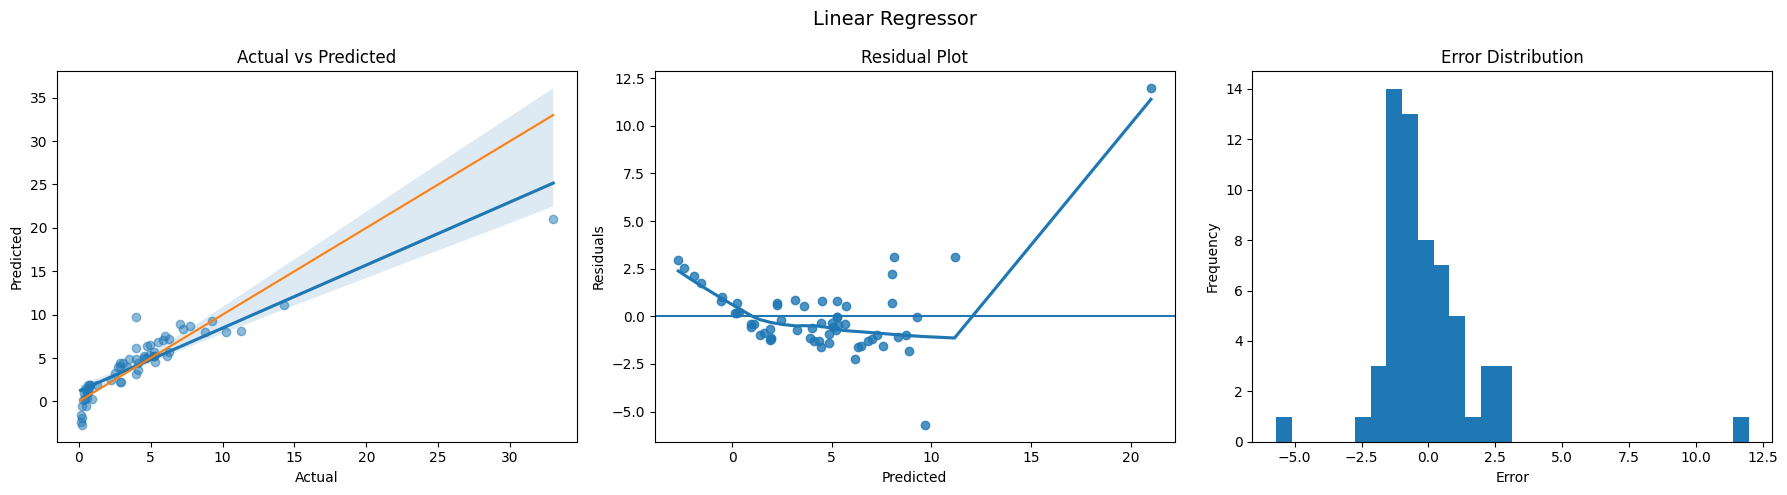

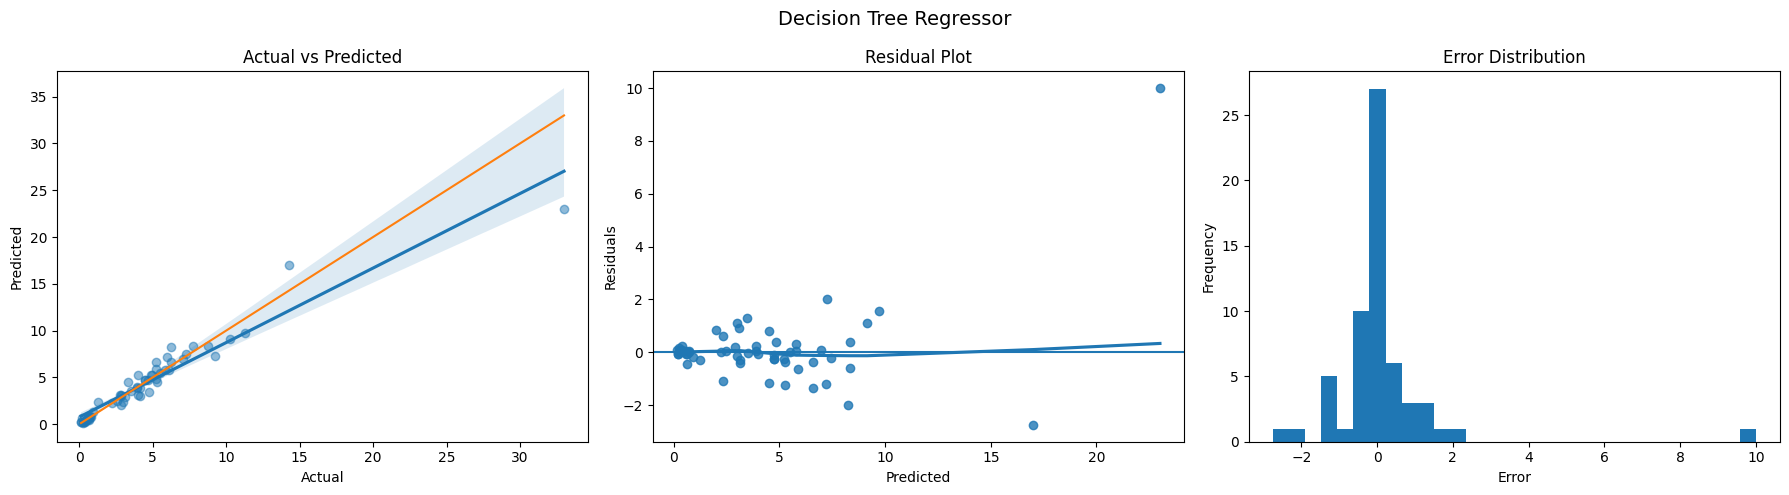

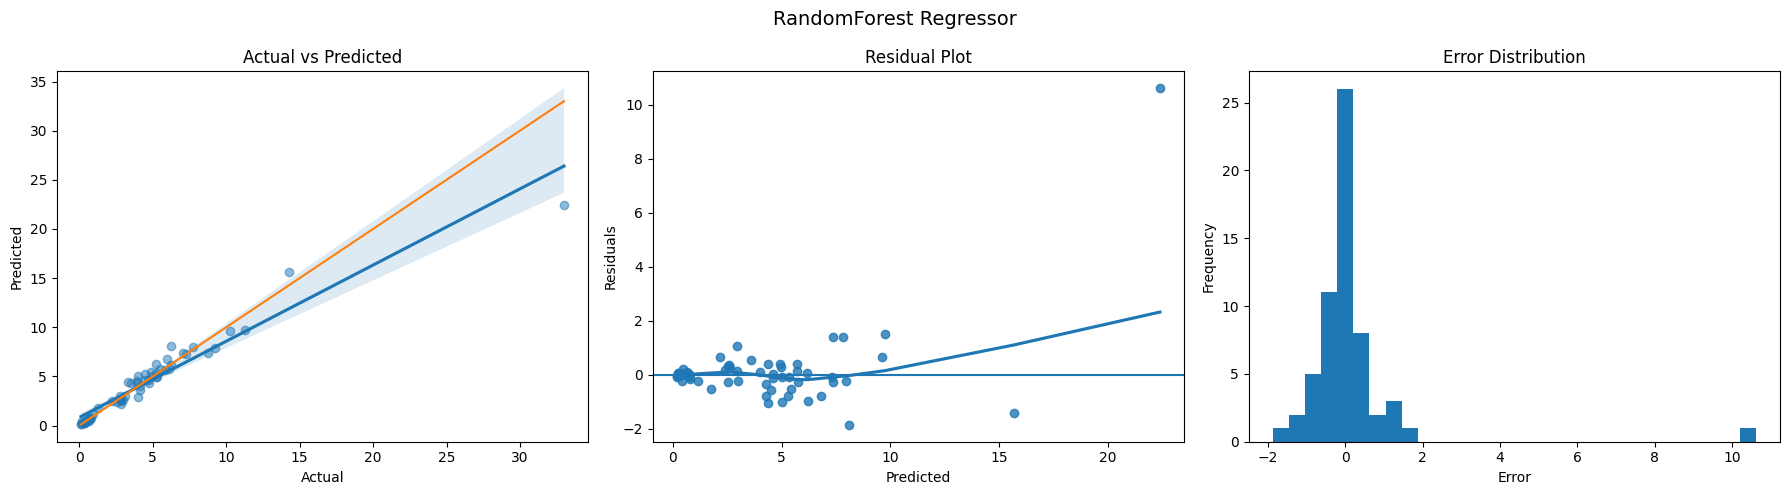

In [193]:
results = train_models(X_train, X_test, Y_train, Y_test)

In [194]:
results

{'Linear Regressor': {'R2 Score': 80.6125740537147,
  'MSE': 4.50866836233048,
  'RMSE': 2.1233625131687903,
  'MAE': 1.3005622707091387},
 'Decision Tree Regressor': {'R2 Score': 90.36125943682562,
  'MSE': 2.2415499999999997,
  'RMSE': 1.4971806838187567,
  'MAE': 0.645},
 'RandomForest Regressor': {'R2 Score': 90.39752470852822,
  'MSE': 2.233116281999999,
  'RMSE': 1.4943614964258143,
  'MAE': 0.578026666666667}}

**Model Results**

- `Linear Regression` achieved `80.6% r2 score` and coming to model evaluation RMSE achieved `2.12 lakh error and MAE is 1.3 lakh error`

where our linear model slightly underfitted as we seen in residual pattern and as we see in error distribution our data mostly in right skewness

- `Decision Tree Regressor` achieved `90.36% r2 score` which is better than linear model but model is overfitted as we seen in residual pattern as sharp

similarly model evaluation our model achieved `RMSE is 1.49 lakh and MAE is 0.64 lakh` and error distribution is right skew better than linear model

- `Random Forest Regressor` achieved `90.39% r2 score` which is slightly better than decision tree and our model performed better generalization than decision tree and similar to decision tree but slightly better

and coming to model evaluation our again RMSE is 1.49lakh and MAE is 0.57 thousand

**`Final conclusion:`**
    
   I compared Linear Regression, Decision Tree, & Random Forest, Although Random Forests Achieved high accuarcy and MAE is     lower and Generalized better based on residual analysis, so i selected it as final model.
    
   Random forest regressor performed better than linear and decision tree
    
   Where achieved best
   - `r2 score` : 90.39%  
   - `RMSE` : 1.47, means `1 lakh 47 thousand`
   - `MAE` : 0.57, which is 57 thousand (Error)